# Course 5, Module 2, Lesson 1 Screencasts

## M2L1SC1: Visualizing and Diagnosing Data with EDA

### Visualizing Data Distributions with Histograms

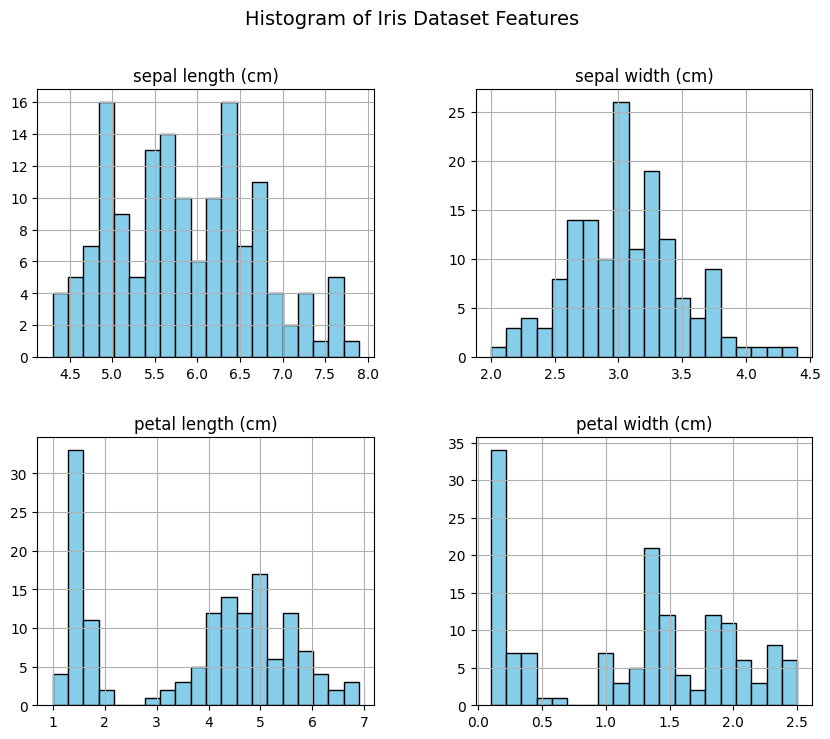

In [ ]:
# Visualizing Data Distributions
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Plot histogram for each feature
df_iris.hist(bins=20, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histogram of Iris Dataset Features', fontsize=14)
plt.show()

### Showing Relationships with Scatterplots

In [ ]:
from scipy.stats import gaussian_kde
import numpy as np

# Create a 2D array for KDE
data = np.vstack([df_diabetes['bmi'], df_diabetes['bp']])

# Use gaussian_kde to estimate the density
kde = gaussian_kde(data)

# Create a meshgrid for density evaluation
x_min, x_max = df_diabetes['bmi'].min() - 0.01, df_diabetes['bmi'].max() + 0.01
y_min, y_max = df_diabetes['bp'].min() - 0.01, df_diabetes['bp'].max() + 0.01
X, Y = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([X.ravel(), Y.ravel()])

# Evaluate the estimated density on the meshgrid
Z = np.reshape(kde(positions).T, X.shape)


Identify the coordinates of the peak density by finding the maximum value in the density grid and converting its index to coordinates.



In [ ]:
# Find the index of the maximum density
max_density_index = np.argmax(Z)

# Convert the flat index to a 2D index
max_density_2d_index = np.unravel_index(max_density_index, Z.shape)

# Get the coordinates of the peak density
peak_density_x = X[max_density_2d_index]
peak_density_y = Y[max_density_2d_index]

# Store the coordinates for later use (already done by assigning to variables)
print(f"Peak density coordinates: ({peak_density_x}, {peak_density_y})")

Peak density coordinates: (-0.026521825506004473, -0.018224516158967252)


In [ ]:
# Calculate the range of the 'bmi' axis
bmi_range = x_max - x_min

# Determine a radius based on a percentage of the BMI range (e.g., 10%)
circle_radius = bmi_range * 0.10

# Print the chosen radius
print(f"Chosen circle radius: {circle_radius}")

Chosen circle radius: 0.028083052187915354


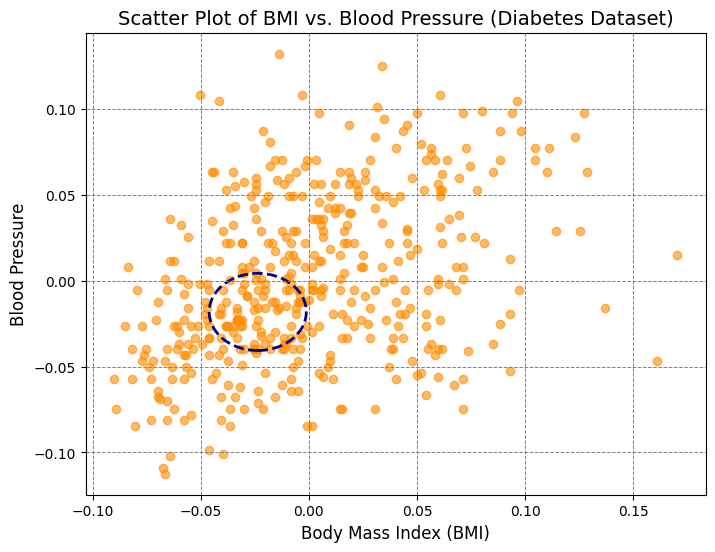

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
import pandas as pd
from matplotlib.patches import Circle
import numpy as np
from scipy.stats import gaussian_kde

# Load Diabetes dataset
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Scatter plot (e.g., 'bmi' vs 'bp')
plt.figure(figsize=(8, 6))
plt.scatter(df_diabetes['bmi'], df_diabetes['bp'], color='darkorange', alpha=0.6)
plt.title('Scatter Plot of BMI vs. Blood Pressure (Diabetes Dataset)', fontsize=14)
plt.xlabel('Body Mass Index (BMI)', fontsize=12)
plt.ylabel('Blood Pressure', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.7, color='gray')

# Existing code to find peak density and radius
data = np.vstack([df_diabetes['bmi'], df_diabetes['bp']])

# Adjust the bandwidth for KDE
# kde = gaussian_kde(data) # Original bandwidth
kde = gaussian_kde(data, bw_method=0.5) # Reduced bandwidth for more localized density

x_min, x_max = df_diabetes['bmi'].min() - 0.01, df_diabetes['bmi'].max() + 0.01
y_min, y_max = df_diabetes['bp'].min() - 0.01, df_diabetes['bp'].max() + 0.01
X, Y = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)
max_density_index = np.argmax(Z)
max_density_2d_index = np.unravel_index(max_density_index, Z.shape)
peak_density_x = X[max_density_2d_index]
peak_density_y = Y[max_density_2d_index]
bmi_range = x_max - x_min

# Adjust the circle radius calculation
# circle_radius = bmi_range * 0.10 # Original radius calculation
circle_radius = bmi_range * 0.08 # Reduced radius

# Get the current axes
ax = plt.gca()

# Create and add the circle patch
circle = Circle((peak_density_x, peak_density_y), radius=circle_radius, color='navy', fill=False, linestyle='--', linewidth=2)
ax.add_patch(circle)

plt.show()

### Summarizing Data with Box Plots

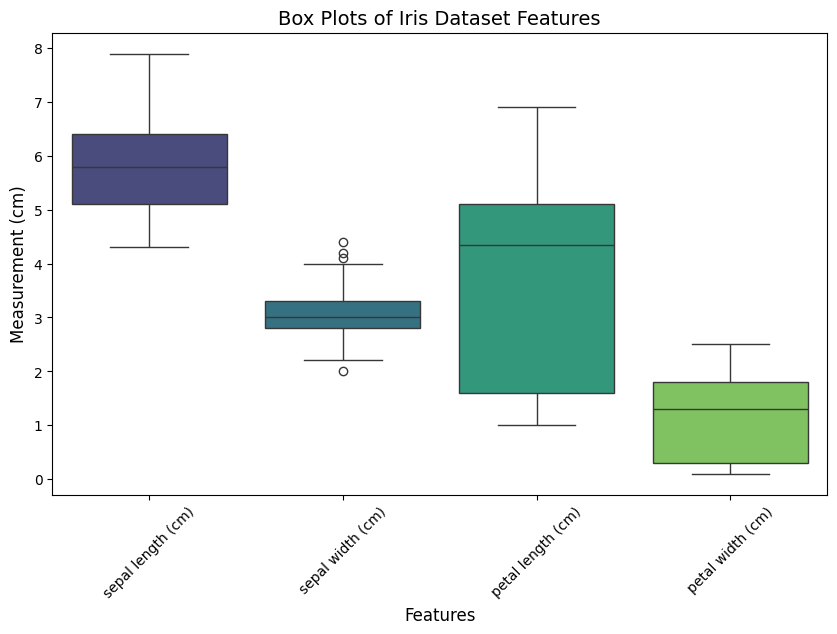

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Create box plots for all numerical features in the Iris dataset
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_iris, palette='viridis')
plt.title('Box Plots of Iris Dataset Features', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Measurement (cm)', fontsize=12)
plt.xticks(fontsize=10, rotation=45) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)
plt.show()

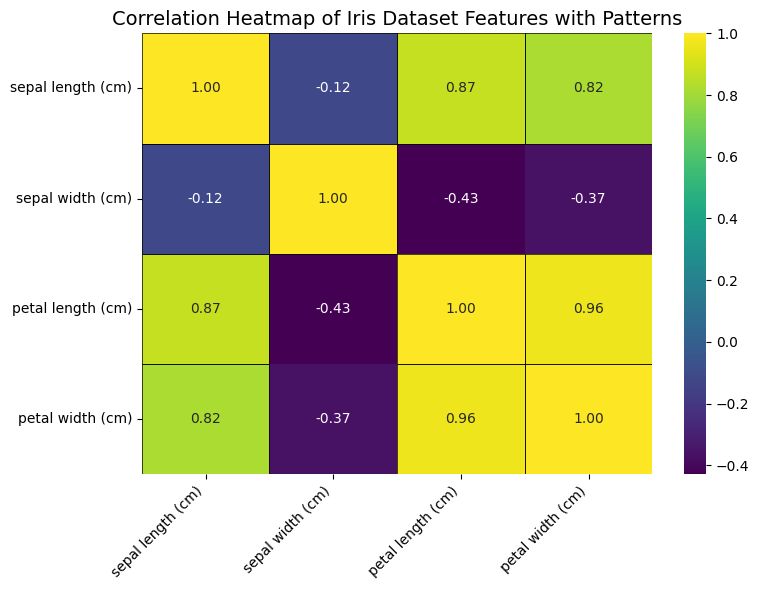

In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import numpy as np

# Calculate the correlation matrix (already done in a previous cell, but included for completeness)
# corr_matrix = df_iris.corr()

# Generate the heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', annot_kws={'fontsize':10}, fmt=".2f", ax=ax, cbar=True) # Added ax=ax and cbar=True for clearer access to axes

plt.title('Correlation Heatmap of Iris Dataset Features with Patterns', fontsize=14)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.tight_layout()

# Define pattern mapping based on correlation values
def get_pattern(value):
    if value > 0.7:
        return '/'  # Strong positive correlation
    elif value < -0.7:
        return '\\' # Strong negative correlation
    elif abs(value) < 0.3:
        return 'x'  # Weak correlation
    else:
        return None # Moderate correlation, no pattern

# Iterate through the heatmap cells and add patterns
patches = []
# We need to get the actual positions of the cells on the plot.
# The heatmap cells are centered at (j+0.5, i+0.5) in the axes coordinate system,
# where i is the row index and j is the column index of the data matrix.
# The width and height are 1.
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        correlation_value = corr_matrix.iloc[i, j]
        pattern = get_pattern(correlation_value)
        if pattern:
            # Create a rectangle patch for the cell. The coordinates (x, y) are the bottom-left corner.
            # For a cell at row i and column j (0-indexed), the bottom-left corner
            # in the axes coordinate system is (j, i).
            rect = Rectangle((j, i), 1, 1, facecolor='none', edgecolor='black', hatch=pattern, linewidth=0.5)
            patches.append(rect)

# Add all patches to the axes
collection = PatchCollection(patches, match_original=True)
ax.add_collection(collection)

plt.show()

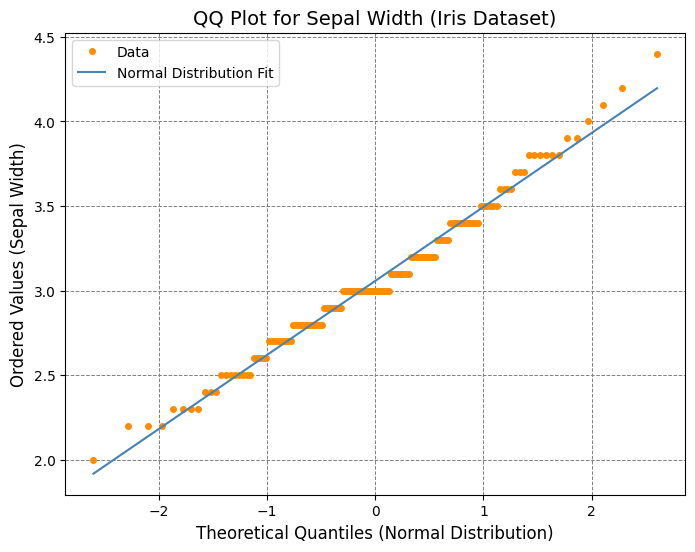

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
import scipy.stats as stats

# Load Iris dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Get the data for the QQ plot
(osm, osr), (slope, intercept, r) = stats.probplot(df_iris['sepal width (cm)'], dist="norm", fit=True)

# Create the figure and axes
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Plot the data points with custom markers and color
ax.plot(osm, osr, marker='o', markersize=4, linestyle='None', color='darkorange', label='Data')

# Plot the fitted line with a contrasting color
line_x = osm
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, color='steelblue', linestyle='-', label='Normal Distribution Fit') # Using 'steelblue' as a shade of blue

plt.title('QQ Plot for Sepal Width (Iris Dataset)', fontsize=14)
plt.xlabel('Theoretical Quantiles (Normal Distribution)', fontsize=12)
plt.ylabel('Ordered Values (Sepal Width)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.7, color='gray')
plt.legend() # Add a legend to distinguish data points and the line
plt.show()